### For Pair Trading, Ensure Pair Correlation > 0.85 

In [30]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

#### Function for Correlation

In [26]:
def evaluate_pair_correlation(stock_a_symbol, stock_b_symbol, start_date, end_date, correlation_threshold=0.85):
    """Evaluate and visualize correlation between two stocks."""
    
    try: 
        # Fetch historical data and remove timezone info for cleaner alignment
        stock_a = yf.Ticker(stock_a_symbol).history(start=start_date, end=end_date)["Close"]
        stock_b = yf.Ticker(stock_b_symbol).history(start=start_date, end=end_date)["Close"]

        if stock_a.empty or stock_b.empty:
            print(f"Error: No data found for {stock_a_symbol if stock_a.empty else stock_b_symbol}")
            return

        # Align data and drop NA (in case of different trading days/holidays)
        # We use .tz_localize(None) to avoid timezone mismatch errors
        combined = pd.DataFrame({
            "A": stock_a.tz_localize(None), 
            "B": stock_b.tz_localize(None)
        }).dropna()

        # Minimum data points check
        if len(combined) < 20:  
            print(f"Error: Insufficient overlapping data points ({len(combined)})")
            return

        # Normalize to 100 for visual comparison
        norm_a = (combined["A"] / combined["A"].iloc[0]) * 100
        norm_b = (combined["B"] / combined["B"].iloc[0]) * 100
    
        # Plotting
        plt.figure(figsize=(12, 6))
        plt.plot(norm_a.index, norm_a, label=f"{stock_a_symbol} (Normalized)", linewidth=2)
        plt.plot(norm_b.index, norm_b, label=f"{stock_b_symbol} (Normalized)", linewidth=2)
        plt.title(f"Price Movement: {stock_a_symbol} vs {stock_b_symbol}", fontsize=14, fontweight='bold')
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Normalized Price (Base = 100)", fontsize=12)
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
        # Compute correlation
        correlation = combined["A"].corr(combined["B"])
        print(f"\n{'='*60}")
        print(f"Correlation between {stock_a_symbol} and {stock_b_symbol}: {correlation:.4f}")
        print(f"Data points analyzed: {len(combined)}")
        print(f"Period: {combined.index[0].strftime('%Y-%m-%d')} to {combined.index[-1].strftime('%Y-%m-%d')}")
        print(f"{'='*60}\n")
    
        # Determine if suitable for pair trading
        if correlation > correlation_threshold:
            print(f"✓ Strong correlation ({correlation:.4f}) - Potentially suitable for pair trading")
        elif correlation > 0.70:
            print(f"⚠ Moderate correlation ({correlation:.4f}) - Marginal for pair trading")
        else:
            print(f"✗ Weak correlation ({correlation:.4f}) - Not suitable for pair trading")

    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Example usage:
# evaluate_pair_correlation("PEP", "KO", "2025-01-01", "2026-01-01")


In [ ]:
evaluate_pair_correlation("O39.SI", "U11.SI", start_date="2024-01-01", end_date="2024-12-31")

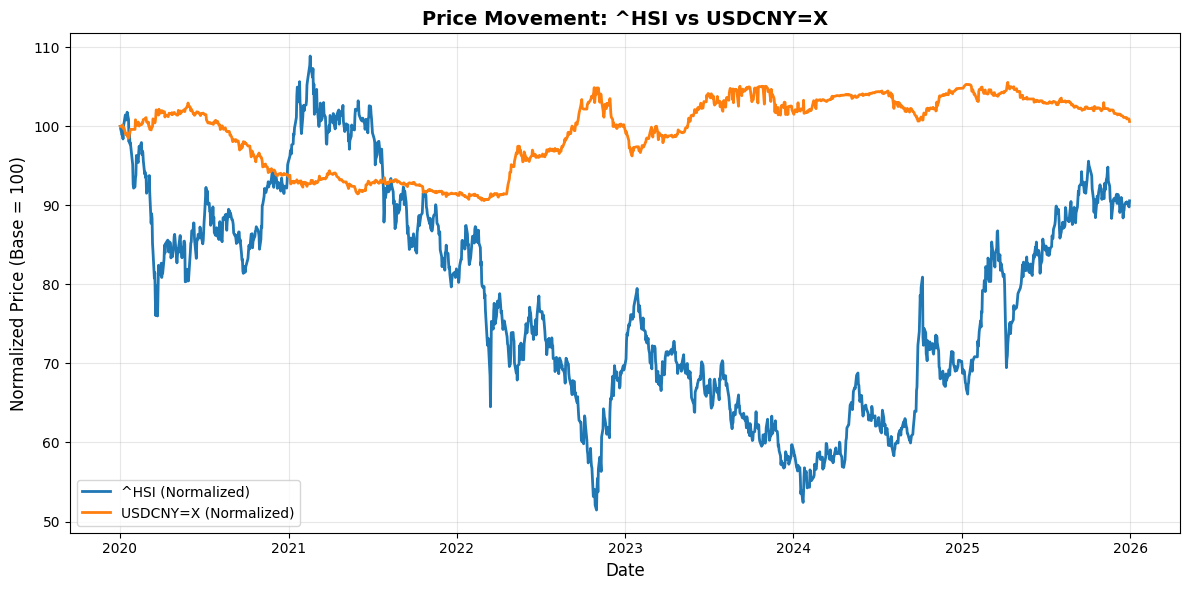


Correlation between ^HSI and USDCNY=X: -0.5693
Data points analyzed: 1475
Period: 2020-01-02 to 2025-12-30

✗ Weak correlation (-0.5693) - Not suitable for pair trading


In [35]:
evaluate_pair_correlation("^HSI", "USDCNY=X", start_date="2020-01-01", end_date="2025-12-31")

#### Functiopn for Rolling Correlation

In [37]:
def evaluate_pair_correlation(stock_a_symbol, stock_b_symbol, start_date, end_date, 
                               correlation_threshold=0.85, rolling_window=60):
    """Evaluate and visualize correlation between two stocks with rolling correlation."""
    
    try: 
        # Fetch historical data and remove timezone info for cleaner alignment
        stock_a = yf.Ticker(stock_a_symbol).history(start=start_date, end=end_date)["Close"]
        stock_b = yf.Ticker(stock_b_symbol).history(start=start_date, end=end_date)["Close"]

        if stock_a.empty or stock_b.empty:
            print(f"Error: No data found for {stock_a_symbol if stock_a.empty else stock_b_symbol}")
            return

        # Align data and drop NA (in case of different trading days/holidays)
        combined = pd.DataFrame({
            "A": stock_a.tz_localize(None), 
            "B": stock_b.tz_localize(None)
        }).dropna()

        # Minimum data points check
        if len(combined) < rolling_window:  
            print(f"Error: Insufficient data points ({len(combined)}) for {rolling_window}-day rolling correlation")
            return

        # Normalize to 100 for visual comparison
        norm_a = (combined["A"] / combined["A"].iloc[0]) * 100
        norm_b = (combined["B"] / combined["B"].iloc[0]) * 100
        
        # Calculate rolling correlation
        rolling_corr = combined["A"].rolling(window=rolling_window).corr(combined["B"])
    
        # Create subplots: Price movement + Rolling correlation
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        # Plot 1: Normalized price movement
        ax1.plot(norm_a.index, norm_a, label=f"{stock_a_symbol}", linewidth=2, color='#2E86AB')
        ax1.plot(norm_b.index, norm_b, label=f"{stock_b_symbol}", linewidth=2, color='#A23B72')
        ax1.set_title(f"Price Movement: {stock_a_symbol} vs {stock_b_symbol}", 
                      fontsize=14, fontweight='bold', pad=15)
        ax1.set_ylabel("Normalized Price (Base = 100)", fontsize=11)
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3, linestyle='--')
        
        # Plot 2: Rolling correlation
        ax2.plot(rolling_corr.index, rolling_corr, label=f'{rolling_window}-Day Rolling Correlation', 
                 linewidth=2.5, color='#F18F01')
        ax2.axhline(y=correlation_threshold, color='green', linestyle='--', 
                    linewidth=1.5, label=f'Threshold ({correlation_threshold})')
        ax2.axhline(y=0.70, color='orange', linestyle='--', 
                    linewidth=1.5, alpha=0.7, label='Moderate (0.70)')
        ax2.axhline(y=0, color='red', linestyle='-', 
                    linewidth=1, alpha=0.5)
        ax2.fill_between(rolling_corr.index, correlation_threshold, 1.0, 
                         alpha=0.1, color='green', label='Strong Correlation Zone')
        ax2.set_title(f"{rolling_window}-Day Rolling Correlation", 
                      fontsize=14, fontweight='bold', pad=15)
        ax2.set_xlabel("Date", fontsize=11)
        ax2.set_ylabel("Correlation Coefficient", fontsize=11)
        ax2.set_ylim(-1, 1)
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.show()
    
        # Statistical Summary
        overall_corr = combined["A"].corr(combined["B"])
        mean_rolling_corr = rolling_corr.mean()
        std_rolling_corr = rolling_corr.std()
        min_rolling_corr = rolling_corr.min()
        max_rolling_corr = rolling_corr.max()
        current_corr = rolling_corr.iloc[-1]
        
        # Time above threshold
        above_threshold = (rolling_corr > correlation_threshold).sum()
        total_periods = rolling_corr.notna().sum()
        pct_above_threshold = (above_threshold / total_periods) * 100 if total_periods > 0 else 0
        
        print(f"\n{'='*70}")
        print(f"CORRELATION ANALYSIS: {stock_a_symbol} vs {stock_b_symbol}")
        print(f"{'='*70}")
        print(f"Period: {combined.index[0].strftime('%Y-%m-%d')} to {combined.index[-1].strftime('%Y-%m-%d')}")
        print(f"Data points: {len(combined)}")
        print(f"\n--- OVERALL STATISTICS ---")
        print(f"Overall Correlation (Full Period):  {overall_corr:>8.4f}")
        print(f"\n--- ROLLING {rolling_window}-DAY CORRELATION ---")
        print(f"Current ({rolling_corr.index[-1].strftime('%Y-%m-%d')}):  {current_corr:>8.4f}")
        print(f"Mean:                                {mean_rolling_corr:>8.4f}")
        print(f"Std Deviation:                       {std_rolling_corr:>8.4f}")
        print(f"Min:                                 {min_rolling_corr:>8.4f}")
        print(f"Max:                                 {max_rolling_corr:>8.4f}")
        print(f"\n--- STABILITY METRICS ---")
        print(f"% Time Above Threshold ({correlation_threshold}): {pct_above_threshold:>6.2f}%")
        print(f"{'='*70}\n")
    
        # Trading suitability assessment
        if current_corr > correlation_threshold and mean_rolling_corr > correlation_threshold:
            print(f"✓ STRONG PAIR - Current & mean rolling correlation above {correlation_threshold}")
            print(f"  → High confidence for pair trading strategy")
        elif current_corr > 0.70 and mean_rolling_corr > 0.70:
            print(f"⚠ MODERATE PAIR - Acceptable but monitor for breakdown")
            print(f"  → Consider shorter holding periods or tighter stops")
        else:
            print(f"✗ WEAK PAIR - Unstable correlation relationship")
            print(f"  → Not recommended for pair trading")
            
        # Regime change warning
        if std_rolling_corr > 0.20:
            print(f"\n⚠ HIGH VOLATILITY: Correlation std dev = {std_rolling_corr:.4f}")
            print(f"  → Relationship instability detected - use dynamic hedge ratios")

    except Exception as e:
        print(f"An unexpected error occurred: {e}")


# Example usage
#evaluate_pair_correlation("^HSI", "USDCNY=X", start_date="2020-01-01", end_date="2025-12-31")


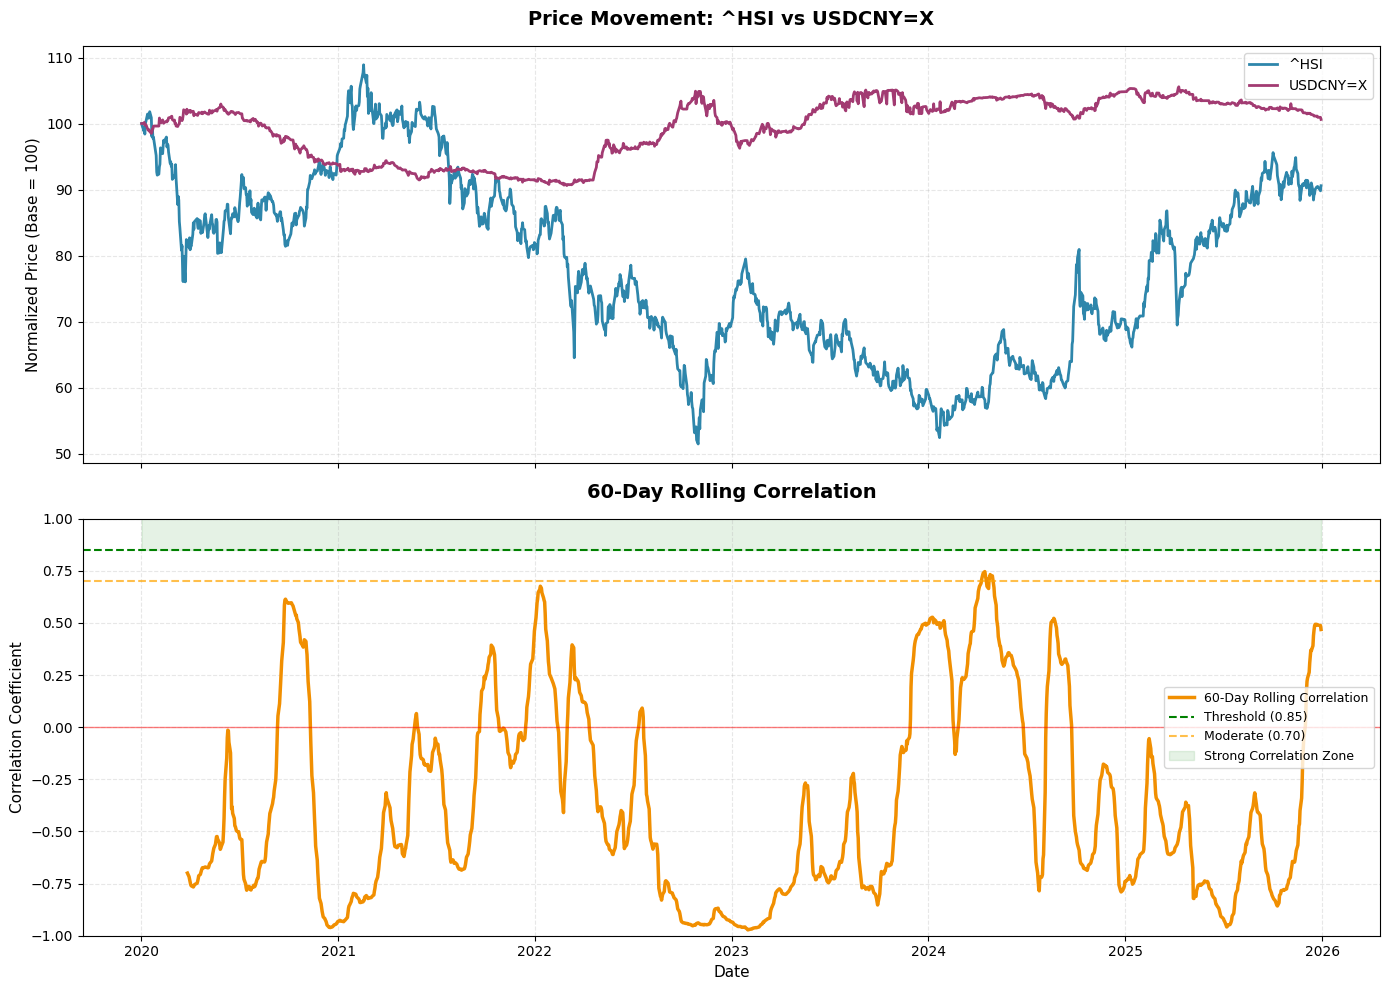


CORRELATION ANALYSIS: ^HSI vs USDCNY=X
Period: 2020-01-02 to 2025-12-30
Data points: 1475

--- OVERALL STATISTICS ---
Overall Correlation (Full Period):   -0.5693

--- ROLLING 60-DAY CORRELATION ---
Current (2025-12-30):    0.4684
Mean:                                 -0.3698
Std Deviation:                         0.4697
Min:                                  -0.9720
Max:                                   0.7461

--- STABILITY METRICS ---
% Time Above Threshold (0.85):   0.00%

✗ WEAK PAIR - Unstable correlation relationship
  → Not recommended for pair trading

⚠ HIGH VOLATILITY: Correlation std dev = 0.4697
  → Relationship instability detected - use dynamic hedge ratios


In [38]:
evaluate_pair_correlation("^HSI", "USDCNY=X", start_date="2020-01-01", end_date="2025-12-31")

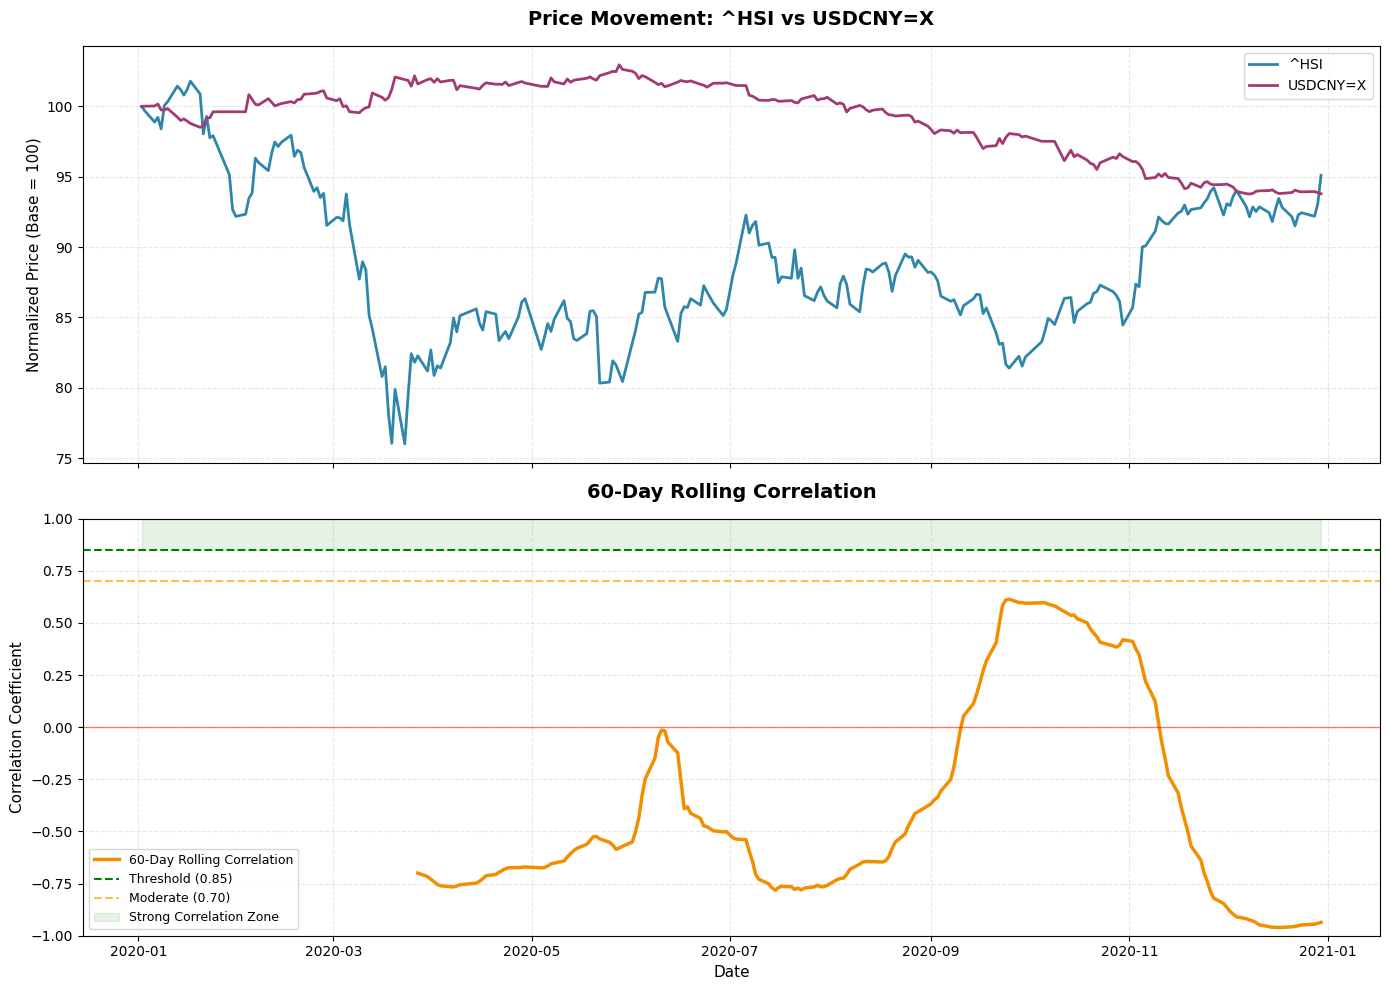


CORRELATION ANALYSIS: ^HSI vs USDCNY=X
Period: 2020-01-02 to 2020-12-30
Data points: 247

--- OVERALL STATISTICS ---
Overall Correlation (Full Period):   -0.3485

--- ROLLING 60-DAY CORRELATION ---
Current (2020-12-30):   -0.9359
Mean:                                 -0.4002
Std Deviation:                         0.4738
Min:                                  -0.9608
Max:                                   0.6139

--- STABILITY METRICS ---
% Time Above Threshold (0.85):   0.00%

✗ WEAK PAIR - Unstable correlation relationship
  → Not recommended for pair trading

⚠ HIGH VOLATILITY: Correlation std dev = 0.4738
  → Relationship instability detected - use dynamic hedge ratios


In [39]:
evaluate_pair_correlation("^HSI", "USDCNY=X", start_date="2020-01-01", end_date="2020-12-31")

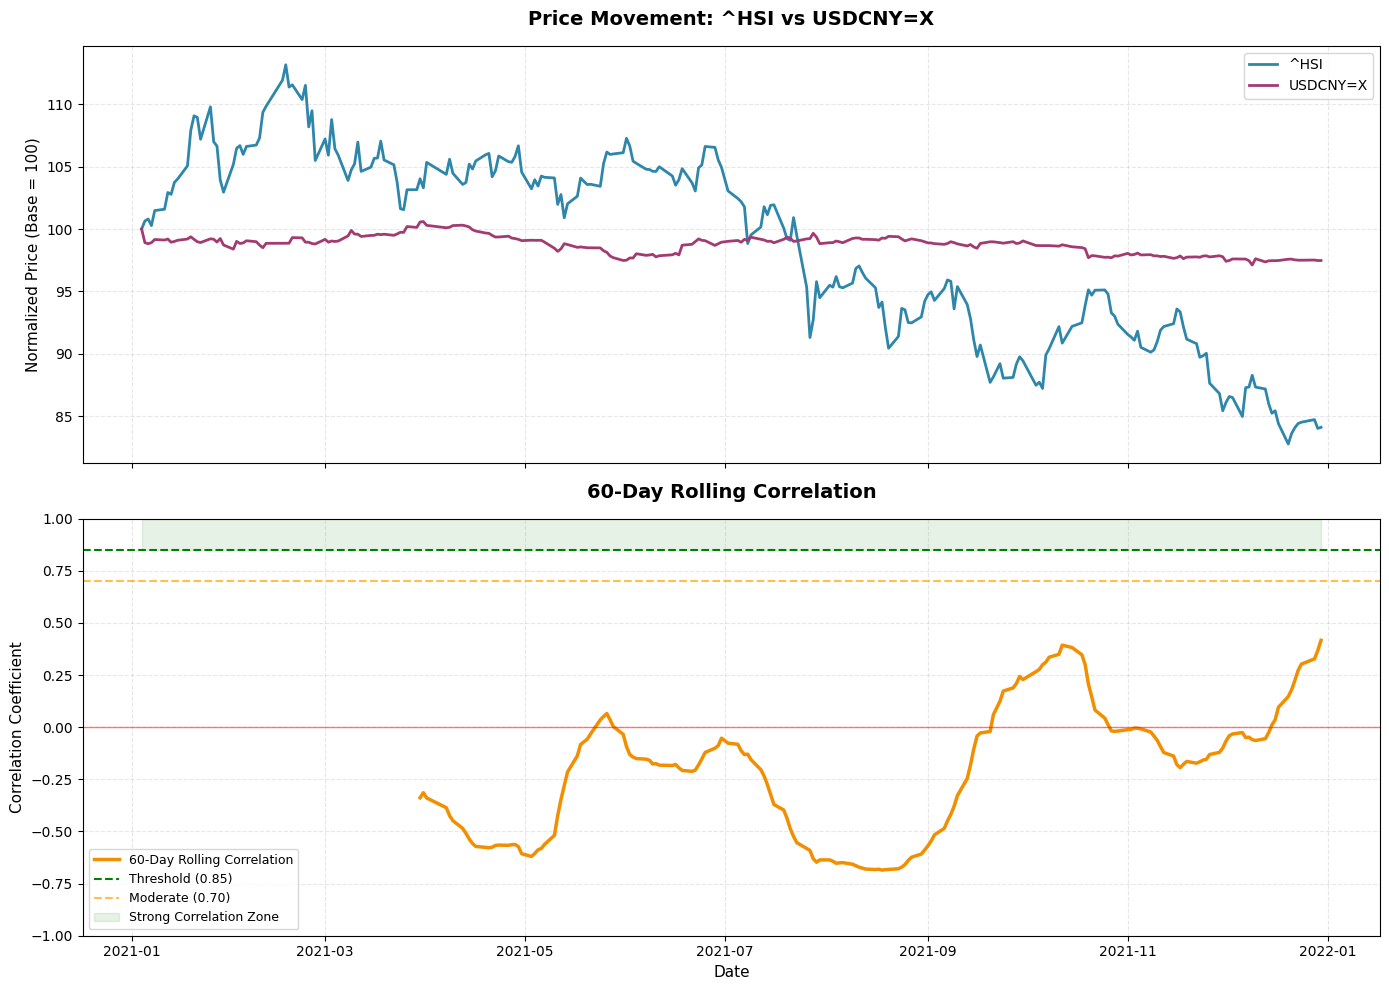


CORRELATION ANALYSIS: ^HSI vs USDCNY=X
Period: 2021-01-04 to 2021-12-30
Data points: 246

--- OVERALL STATISTICS ---
Overall Correlation (Full Period):    0.5159

--- ROLLING 60-DAY CORRELATION ---
Current (2021-12-30):    0.4165
Mean:                                 -0.2169
Std Deviation:                         0.3040
Min:                                  -0.6854
Max:                                   0.4165

--- STABILITY METRICS ---
% Time Above Threshold (0.85):   0.00%

✗ WEAK PAIR - Unstable correlation relationship
  → Not recommended for pair trading

⚠ HIGH VOLATILITY: Correlation std dev = 0.3040
  → Relationship instability detected - use dynamic hedge ratios


In [40]:
evaluate_pair_correlation("^HSI", "USDCNY=X", start_date="2021-01-01", end_date="2021-12-31")

#### Function for Cointegration


In [31]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

def evaluate_pair_trading(stock_a_symbol, stock_b_symbol, start_date, end_date):
    """Evaluate correlation and cointegration for pairs trading."""
    
    try: 
        # 1. Data Retrieval
        a_data = yf.Ticker(stock_a_symbol).history(start=start_date, end=end_date)["Close"]
        b_data = yf.Ticker(stock_b_symbol).history(start=start_date, end=end_date)["Close"]

        combined = pd.DataFrame({
            "A": a_data.tz_localize(None), 
            "B": b_data.tz_localize(None)
        }).dropna()

        if len(combined) < 30:
            print("Error: Not enough data points.")
            return

        # 2. Cointegration Test (Engle-Granger)
        # Returns: t-statistic, p-value, and critical values
        score, p_value, _ = coint(combined["A"], combined["B"])

        # 3. Calculate the Spread
        # Simple Spread: A - (hedge_ratio * B)
        # We use OLS regression to find the hedge ratio (beta)
        X = sm.add_constant(combined["B"])
        model = sm.OLS(combined["A"], X).fit()
        hedge_ratio = model.params[1]
        spread = combined["A"] - (hedge_ratio * combined["B"])

        # 4. Visualization
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        # Plot 1: Normalized Prices
        norm_a = (combined["A"] / combined["A"].iloc[0]) * 100
        norm_b = (combined["B"] / combined["B"].iloc[0]) * 100
        ax1.plot(norm_a, label=stock_a_symbol)
        ax1.plot(norm_b, label=stock_b_symbol)
        ax1.set_title(f"Normalized Price Movement")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Plot 2: The Spread (The "Stationary" Series)
        ax2.plot(spread, color='purple', label='Spread (A - β*B)')
        ax2.axhline(spread.mean(), color='black', linestyle='--')
        ax2.set_title(f"Spread Analysis (Hedge Ratio: {hedge_ratio:.2f})")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # 5. Summary Output
        correlation = combined["A"].corr(combined["B"])
        
        print(f"\n{'='*40}")
        print(f"ANALYSIS: {stock_a_symbol} vs {stock_b_symbol}")
        print(f"{'='*40}")
        print(f"Correlation:  {correlation:.4f}")
        print(f"Coint P-Value: {p_value:.4f}")
        
        if p_value < 0.05:
            print("Result: ✓ COINTEGRATED. The spread is mean-reverting.")
        else:
            print("Result: ✗ NOT COINTEGRATED. The spread may drift apart.")
        print(f"{'='*40}\n")

    except Exception as e:
        print(f"Error: {e}")

# Example test:
# evaluate_pair_trading("EWA", "EWC", "2024-01-01", "2026-01-01")

### Mean Reversion Pairs Trading Strategy
Entry: Enter a short spread (short DBS, long OCBC) when the z-score > 2. Enter a long spread when the z-score < -2.
Exit: Close positions when the z-score returns to 0

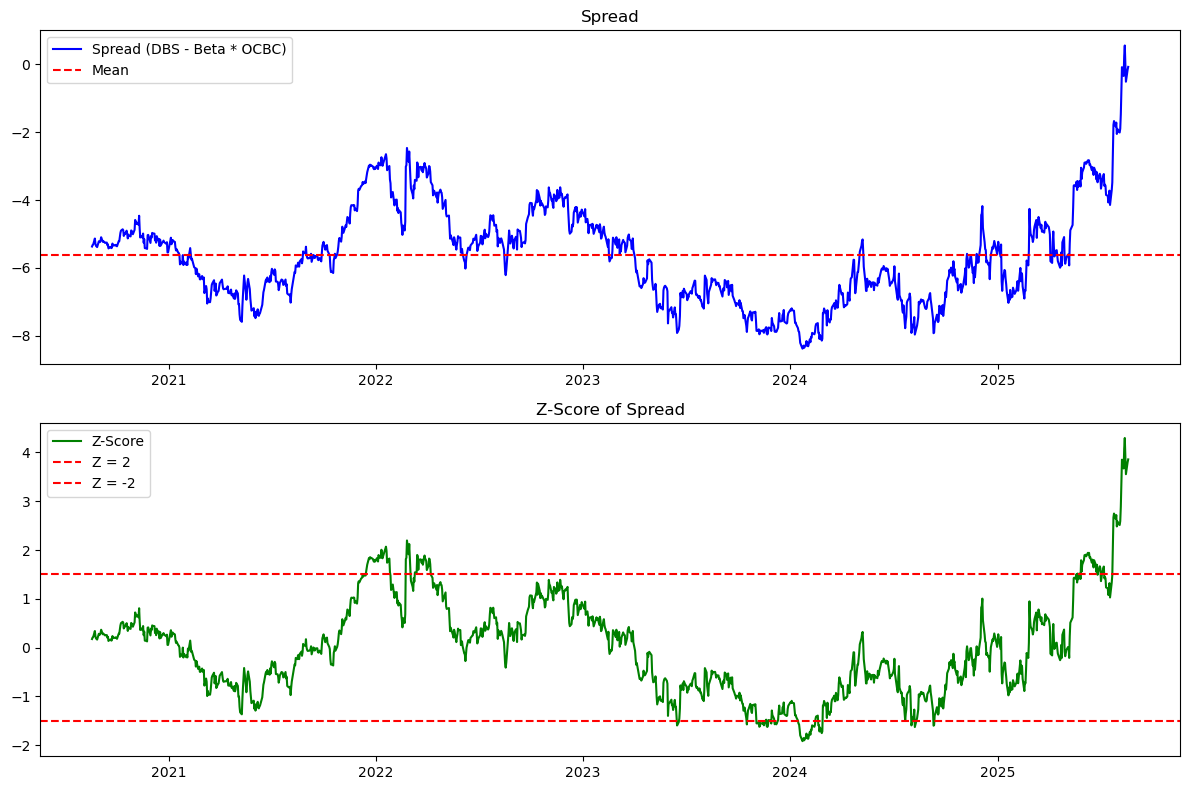

                           Signal      Position
Date                                           
2025-08-06 00:00:00+08:00      -1  Short Spread
2025-08-07 00:00:00+08:00      -1  Short Spread
2025-08-08 00:00:00+08:00      -1  Short Spread
2025-08-11 00:00:00+08:00      -1  Short Spread
2025-08-12 00:00:00+08:00      -1  Short Spread
2025-08-13 00:00:00+08:00      -1  Short Spread
2025-08-14 00:00:00+08:00      -1  Short Spread
2025-08-15 00:00:00+08:00      -1  Short Spread
2025-08-18 00:00:00+08:00      -1  Short Spread
2025-08-19 00:00:00+08:00      -1  Short Spread


In [4]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Define start and end dates for a 2-year period
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=5)

# Fetch historical data
ocbc = yf.Ticker("O39.SI").history(start=start_date, end=end_date)['Close']
dbs = yf.Ticker("D05.SI").history(start=start_date, end=end_date)['Close']

# Ensure aligned dates
prices = pd.DataFrame({'OCBC': ocbc, 'DBS': dbs}).dropna()

# Linear regression to find the hedge ratio (beta)
x = add_constant(prices['OCBC'])  # OCBC as independent variable
y = prices['DBS']  # DBS as dependent variable
model = OLS(y, x).fit()
beta = model.params['OCBC']

# Calculate the spread
spread = prices['DBS'] - beta * prices['OCBC']

# Calculate z-score for the spread
spread_mean = spread.mean()
spread_std = spread.std()
z_score = (spread - spread_mean) / spread_std

# Plot the spread and z-score
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(spread, label='Spread (DBS - Beta * OCBC)', color='blue')
ax[0].axhline(spread_mean, color='red', linestyle='--', label='Mean')
ax[0].set_title('Spread')
ax[0].legend()

ax[1].plot(z_score, label='Z-Score', color='green')
ax[1].axhline(1.5, color='red', linestyle='--', label='Z = 2')
ax[1].axhline(-1.5, color='red', linestyle='--', label='Z = -2')
ax[1].set_title('Z-Score of Spread')
ax[1].legend()
plt.tight_layout()
plt.show()

# Strategy implementation
def mean_reversion_strategy(spread, z_score, entry_z=1.5, exit_z=0):
    signals = []
    position = 0  # 1 for long, -1 for short, 0 for no position

    for z in z_score:
        if position == 0:
            if z > entry_z:
                signals.append(-1)  # Short spread (short DBS, long OCBC)
                position = -1
            elif z < -entry_z:
                signals.append(1)  # Long spread (long DBS, short OCBC)
                position = 1
            else:
                signals.append(0)
        elif position == 1:
            if z >= exit_z:
                signals.append(0)  # Exit long position
                position = 0
            else:
                signals.append(1)
        elif position == -1:
            if z <= -exit_z:
                signals.append(0)  # Exit short position
                position = 0
            else:
                signals.append(-1)

    return signals

# Apply the strategy
signals = mean_reversion_strategy(spread, z_score)
prices['Signal'] = signals

# Plot positions
prices['Position'] = prices['Signal'].replace({1: 'Long Spread', -1: 'Short Spread', 0: 'No Position'})
print(prices[['Signal', 'Position']].tail(10))


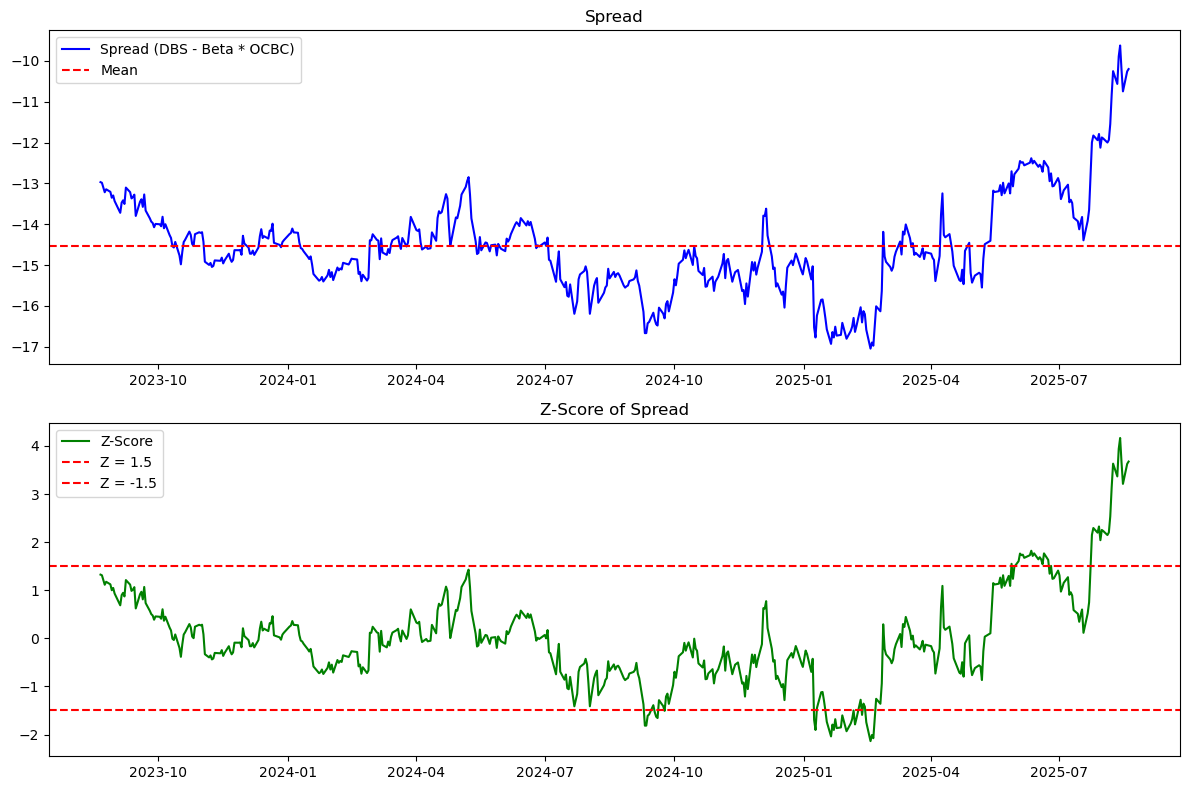

Total Profit/Loss: 5.21 SGD
Last few entry and exit prices:
Trade 1: Entry None, Exit None
Trade 2: Entry None, Exit None
Trade 3: Entry None, Exit None
Trade 4: Entry None, Exit None
Trade 5: Entry (15.938233375549316, 44.49183654785156), Exit None


In [5]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Define start and end dates for a 2-year period
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=2)

# Fetch historical data
ocbc = yf.Ticker("O39.SI").history(start=start_date, end=end_date)['Close']
dbs = yf.Ticker("D05.SI").history(start=start_date, end=end_date)['Close']

# Ensure aligned dates
prices = pd.DataFrame({'OCBC': ocbc, 'DBS': dbs}).dropna()

# Linear regression to find the hedge ratio (beta)
x = add_constant(prices['OCBC'])  # OCBC as independent variable
y = prices['DBS']  # DBS as dependent variable
model = OLS(y, x).fit()
beta = model.params['OCBC']

# Calculate the spread
spread = prices['DBS'] - beta * prices['OCBC']

# Calculate z-score for the spread
spread_mean = spread.mean()
spread_std = spread.std()
z_score = (spread - spread_mean) / spread_std

# Plot the spread and z-score
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(spread, label='Spread (DBS - Beta * OCBC)', color='blue')
ax[0].axhline(spread_mean, color='red', linestyle='--', label='Mean')
ax[0].set_title('Spread')
ax[0].legend()

ax[1].plot(z_score, label='Z-Score', color='green')
ax[1].axhline(1.5, color='red', linestyle='--', label='Z = 1.5')
ax[1].axhline(-1.5, color='red', linestyle='--', label='Z = -1.5')
ax[1].set_title('Z-Score of Spread')
ax[1].legend()
plt.tight_layout()
plt.show()

# Strategy implementation with price tracking
def mean_reversion_strategy(spread, z_score, prices, entry_z=1.5, exit_z=0):
    signals = []
    entry_prices = []
    exit_prices = []
    position = 0  # 1 for long, -1 for short, 0 for no position
    profit_loss = 0.0

    for i, z in enumerate(z_score):
        if position == 0:
            if z > entry_z:
                signals.append(-1)  # Short spread
                position = -1
                entry_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
            elif z < -entry_z:
                signals.append(1)  # Long spread
                position = 1
                entry_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
            else:
                signals.append(0)
                entry_prices.append(None)
                exit_prices.append(None)
        elif position == 1:
            if z >= exit_z:
                signals.append(0)  # Exit long
                position = 0
                exit_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
                ocbc_entry, dbs_entry = entry_prices[-1]
                ocbc_exit, dbs_exit = exit_prices[-1]
                profit_loss += (dbs_exit - dbs_entry) - beta * (ocbc_exit - ocbc_entry)
            else:
                signals.append(1)
                exit_prices.append(None)
        elif position == -1:
            if z <= -exit_z:
                signals.append(0)  # Exit short
                position = 0
                exit_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
                ocbc_entry, dbs_entry = entry_prices[-1]
                ocbc_exit, dbs_exit = exit_prices[-1]
                profit_loss += (dbs_entry - dbs_exit) - beta * (ocbc_entry - ocbc_exit)
            else:
                signals.append(-1)
                exit_prices.append(None)

    return signals, entry_prices, exit_prices, profit_loss

# Apply the strategy
signals, entry_prices, exit_prices, profit_loss = mean_reversion_strategy(spread, z_score, prices)

# Add signals to dataframe
prices['Signal'] = signals

# Display entry, exit, and profit/loss
print(f"Total Profit/Loss: {profit_loss:.2f} SGD")
print("Last few entry and exit prices:")
for i, (entry, exit_) in enumerate(zip(entry_prices[-5:], exit_prices[-5:])):
    print(f"Trade {i + 1}: Entry {entry}, Exit {exit_}")


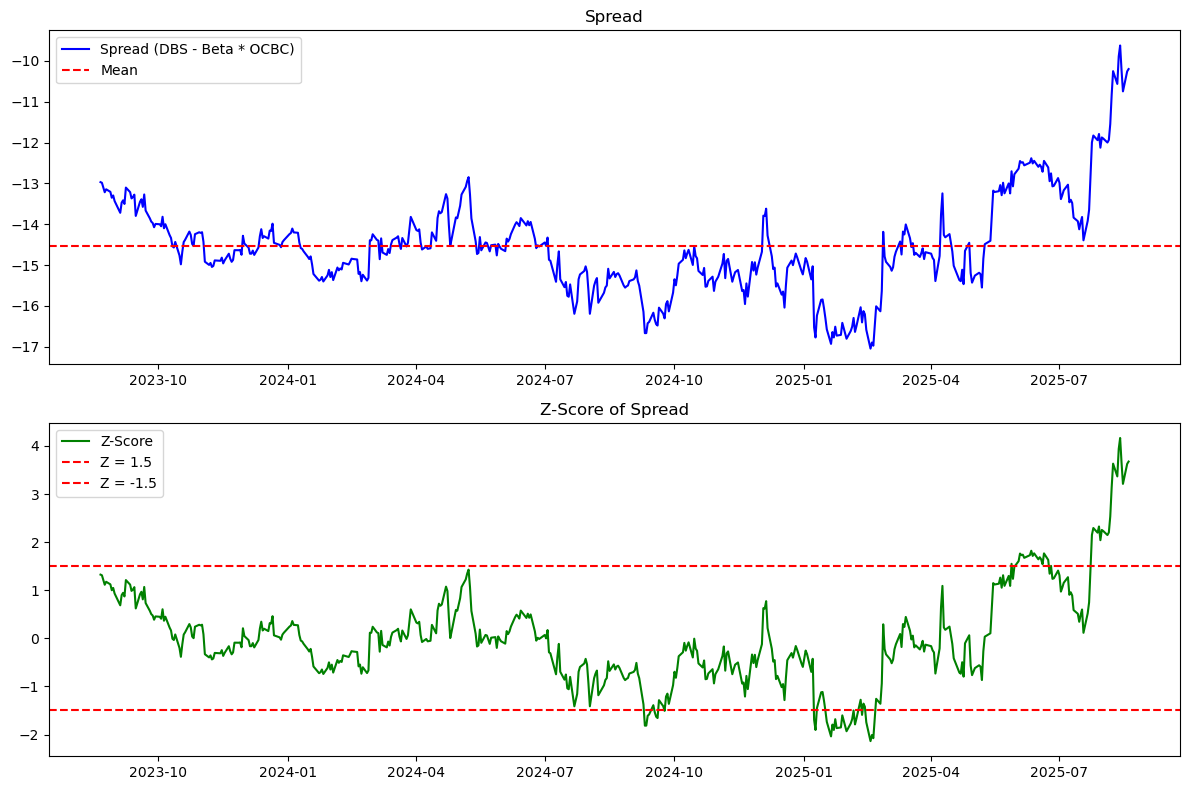

Total Profit/Loss: 521.36 SGD (Quantity = 100)
                                OCBC        DBS
Date                                           
2025-08-06 00:00:00+08:00  16.631201  48.137897
2025-08-07 00:00:00+08:00  16.680000  49.024780
2025-08-08 00:00:00+08:00  16.790001  50.000351
2025-08-11 00:00:00+08:00  16.879999  50.010204
2025-08-12 00:00:00+08:00  16.750000  50.217140
2025-08-13 00:00:00+08:00  16.809999  50.700001
2025-08-14 00:00:00+08:00  16.920000  50.490002
2025-08-15 00:00:00+08:00  16.900000  49.900002
2025-08-18 00:00:00+08:00  16.680000  49.599998
2025-08-19 00:00:00+08:00  16.719999  49.799999


In [6]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Define start and end dates for a 2-year period
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=2)

# Fetch historical data
ocbc = yf.Ticker("O39.SI").history(start=start_date, end=end_date)['Close']
dbs = yf.Ticker("D05.SI").history(start=start_date, end=end_date)['Close']

# Ensure aligned dates
prices = pd.DataFrame({'OCBC': ocbc, 'DBS': dbs}).dropna()

# Linear regression to find the hedge ratio (beta)
x = add_constant(prices['OCBC'])  # OCBC as independent variable
y = prices['DBS']  # DBS as dependent variable
model = OLS(y, x).fit()
beta = model.params['OCBC']

# Calculate the spread
spread = prices['DBS'] - beta * prices['OCBC']

# Calculate z-score for the spread
spread_mean = spread.mean()
spread_std = spread.std()
z_score = (spread - spread_mean) / spread_std

# Strategy implementation with price tracking
def mean_reversion_strategy(spread, z_score, prices, beta, entry_z=1.5, exit_z=0, quantity=100):
    signals = []
    entry_prices = []
    exit_prices = []
    profit_loss = 0.0
    position = 0  # 1 for long, -1 for short, 0 for no position
    trade_dates = []

    for i, z in enumerate(z_score):
        date = prices.index[i]
        if position == 0:
            if z > entry_z:
                signals.append(-1)  # Short spread
                position = -1
                entry_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
                trade_dates.append(date)
            elif z < -entry_z:
                signals.append(1)  # Long spread
                position = 1
                entry_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
                trade_dates.append(date)
            else:
                signals.append(0)
                entry_prices.append(None)
                exit_prices.append(None)
        elif position == 1:
            if z >= exit_z:
                signals.append(0)  # Exit long
                position = 0
                exit_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
                ocbc_entry, dbs_entry = entry_prices[-1]
                ocbc_exit, dbs_exit = exit_prices[-1]
                profit_loss += quantity * ((dbs_exit - dbs_entry) - beta * (ocbc_exit - ocbc_entry))
                trade_dates.append(date)
            else:
                signals.append(1)
                exit_prices.append(None)
        elif position == -1:
            if z <= -exit_z:
                signals.append(0)  # Exit short
                position = 0
                exit_prices.append((prices['OCBC'].iloc[i], prices['DBS'].iloc[i]))
                ocbc_entry, dbs_entry = entry_prices[-1]
                ocbc_exit, dbs_exit = exit_prices[-1]
                profit_loss += quantity * ((dbs_entry - dbs_exit) - beta * (ocbc_entry - ocbc_exit))
                trade_dates.append(date)
            else:
                signals.append(-1)
                exit_prices.append(None)

    return signals, entry_prices, exit_prices, profit_loss, trade_dates

# Apply the strategy
signals, entry_prices, exit_prices, profit_loss, trade_dates = mean_reversion_strategy(spread, z_score, prices, beta)

# Plot the spread and z-score with annotations
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(spread, label='Spread (DBS - Beta * OCBC)', color='blue')
ax[0].axhline(spread_mean, color='red', linestyle='--', label='Mean')
ax[0].set_title('Spread')
ax[0].legend()

# Annotate entry and exit points on spread plot
for i, (entry, exit_, date) in enumerate(zip(entry_prices, exit_prices, trade_dates)):
    if entry and exit_:
        ax[0].annotate('Entry', xy=(date, spread.loc[date]), xytext=(date, spread.loc[date] + 0.05),
                       arrowprops=dict(facecolor='green', shrink=0.5))
        ax[0].annotate('Exit', xy=(date, spread.loc[date]), xytext=(date, spread.loc[date] - 0.05),
                       arrowprops=dict(facecolor='red', shrink=0.5))

ax[1].plot(z_score, label='Z-Score', color='green')
ax[1].axhline(1.5, color='red', linestyle='--', label='Z = 1.5')
ax[1].axhline(-1.5, color='red', linestyle='--', label='Z = -1.5')
ax[1].set_title('Z-Score of Spread')
ax[1].legend()
plt.tight_layout()
plt.show()

# Display total profit/loss
print(f"Total Profit/Loss: {profit_loss:.2f} SGD (Quantity = 100)")
print(prices.tail(10))

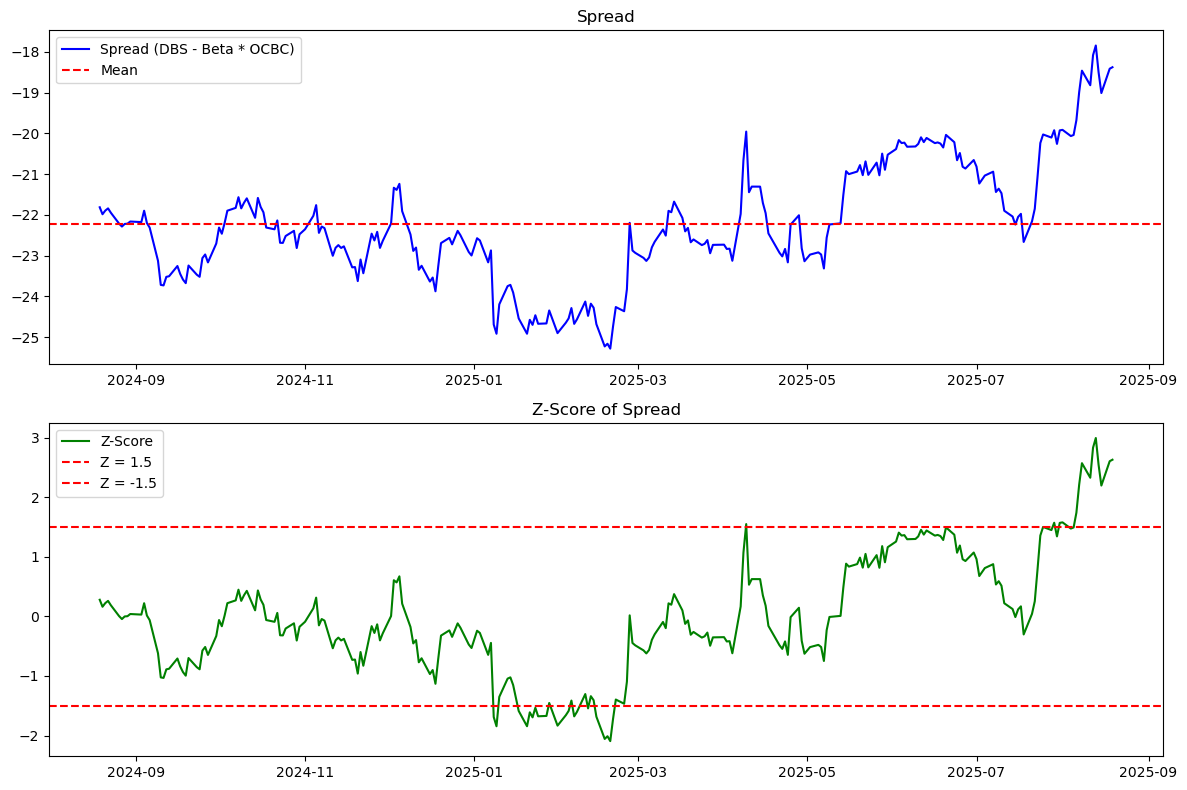

                       Date             Signal  Entry_DBS  Entry_OCBC  \
0 2025-01-08 00:00:00+08:00        Long Spread  43.422813   16.704365   
1 2025-02-26 00:00:00+08:00   Exit Long Spread  43.422813   16.704365   
2 2025-04-09 00:00:00+08:00       Short Spread  36.009357   13.725182   
3 2025-04-17 00:00:00+08:00  Exit Short Spread  36.009357   13.725182   
4 2025-07-25 00:00:00+08:00       Short Spread  48.344841   16.767841   

    Exit_DBS  Exit_OCBC  Shares_DBS  Shares_OCBC  Profit_Loss     Spread  \
0        NaN        NaN  230.293692   598.645931          NaN -24.688646   
1  44.598209  16.380747  224.224249   610.472776  1069.095973 -22.193709   
2        NaN        NaN  277.705594   728.587811          NaN -19.954587   
3  39.565720  15.210014  252.744045   657.461576  3081.655309 -22.452578   
4        NaN        NaN  206.847304   596.379689          NaN -20.025442   

    Z_Score  Cumulative_PnL  
0 -1.689673        0.000000  
1  0.017932     1069.095973  
2  1.550449   

In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# Define start and end dates for a 1-year period
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=1)

# Fetch historical data
ocbc = yf.Ticker("O39.SI").history(start=start_date, end=end_date)['Close']
dbs = yf.Ticker("D05.SI").history(start=start_date, end=end_date)['Close']

# Ensure aligned dates
prices = pd.DataFrame({'OCBC': ocbc, 'DBS': dbs}).dropna()

# Linear regression to find the hedge ratio (beta)
x = add_constant(prices['OCBC'])  # OCBC as independent variable
y = prices['DBS']  # DBS as dependent variable
model = OLS(y, x).fit()
beta = model.params['OCBC']

# Calculate the spread
spread = prices['DBS'] - beta * prices['OCBC']

# Calculate z-score for the spread
spread_mean = spread.mean()
spread_std = spread.std()
z_score = (spread - spread_mean) / spread_std

# Plot the spread and z-score
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(spread, label='Spread (DBS - Beta * OCBC)', color='blue')
ax[0].axhline(spread_mean, color='red', linestyle='--', label='Mean')
ax[0].set_title('Spread')
ax[0].legend()

ax[1].plot(z_score, label='Z-Score', color='green')
ax[1].axhline(1.5, color='red', linestyle='--', label='Z = 1.5')
ax[1].axhline(-1.5, color='red', linestyle='--', label='Z = -1.5')
ax[1].set_title('Z-Score of Spread')
ax[1].legend()
plt.tight_layout()
plt.show()

# Strategy implementation with trade blotter
def mean_reversion_strategy_with_blotter(spread, z_score, prices, beta, entry_z=1.5, exit_z=0, quantity=10000):
    blotter = []
    position = 0  # 1 for long spread (buy DBS, sell OCBC), -1 for short spread (sell DBS, buy OCBC)
    entry_price_dbs = entry_price_ocbc = None

    for i in range(len(z_score)):
        date = spread.index[i]
        z = z_score.iloc[i]
        dbs_price = prices['DBS'].iloc[i]
        ocbc_price = prices['OCBC'].iloc[i]

        # Calculate the number of shares based on equal dollar value
        shares_dbs = quantity / dbs_price
        shares_ocbc = quantity / ocbc_price

        if position == 0:  # No position
            if z > entry_z:  # Enter short spread
                position = -1
                entry_price_dbs = dbs_price
                entry_price_ocbc = ocbc_price
                blotter.append({
                    'Date': date,
                    'Signal': 'Short Spread',
                    'Entry_DBS': entry_price_dbs,
                    'Entry_OCBC': entry_price_ocbc,
                    'Exit_DBS': None,
                    'Exit_OCBC': None,
                    'Shares_DBS': shares_dbs,
                    'Shares_OCBC': shares_ocbc,
                    'Profit_Loss': None,
                    'Spread': spread.iloc[i],
                    'Z_Score': z,
                    'Cumulative_PnL': None
                })
            elif z < -entry_z:  # Enter long spread
                position = 1
                entry_price_dbs = dbs_price
                entry_price_ocbc = ocbc_price
                blotter.append({
                    'Date': date,
                    'Signal': 'Long Spread',
                    'Entry_DBS': entry_price_dbs,
                    'Entry_OCBC': entry_price_ocbc,
                    'Exit_DBS': None,
                    'Exit_OCBC': None,
                    'Shares_DBS': shares_dbs,
                    'Shares_OCBC': shares_ocbc,
                    'Profit_Loss': None,
                    'Spread': spread.iloc[i],
                    'Z_Score': z,
                    'Cumulative_PnL': None
                })
        elif position == 1:  # Long spread (buy DBS, sell OCBC)
            if z >= exit_z:  # Exit long spread
                position = 0
                pnl = (dbs_price - entry_price_dbs) * shares_dbs - beta * (ocbc_price - entry_price_ocbc) * shares_ocbc
                blotter.append({
                    'Date': date,
                    'Signal': 'Exit Long Spread',
                    'Entry_DBS': entry_price_dbs,
                    'Entry_OCBC': entry_price_ocbc,
                    'Exit_DBS': dbs_price,
                    'Exit_OCBC': ocbc_price,
                    'Shares_DBS': shares_dbs,
                    'Shares_OCBC': shares_ocbc,
                    'Profit_Loss': pnl,
                    'Spread': spread.iloc[i],
                    'Z_Score': z,
                    'Cumulative_PnL': None
                })
        elif position == -1:  # Short spread (sell DBS, buy OCBC)
            if z <= -exit_z:  # Exit short spread
                position = 0
                pnl = (entry_price_dbs - dbs_price) * shares_dbs - beta * (entry_price_ocbc - ocbc_price) * shares_ocbc
                blotter.append({
                    'Date': date,
                    'Signal': 'Exit Short Spread',
                    'Entry_DBS': entry_price_dbs,
                    'Entry_OCBC': entry_price_ocbc,
                    'Exit_DBS': dbs_price,
                    'Exit_OCBC': ocbc_price,
                    'Shares_DBS': shares_dbs,
                    'Shares_OCBC': shares_ocbc,
                    'Profit_Loss': pnl,
                    'Spread': spread.iloc[i],
                    'Z_Score': z,
                    'Cumulative_PnL': None
                })

    # Calculate cumulative PnL
    total_pnl = 0
    for trade in blotter:
        if trade['Profit_Loss'] is not None:
            total_pnl += trade['Profit_Loss']
        trade['Cumulative_PnL'] = total_pnl

    return pd.DataFrame(blotter)

# Apply the strategy and generate the blotter
blotter = mean_reversion_strategy_with_blotter(spread, z_score, prices, beta)
print(blotter)

# Total profit/loss
total_pnl = blotter['Profit_Loss'].dropna().sum()
print(f"Total PnL over the period: {total_pnl}")


Visualisation of Z-score

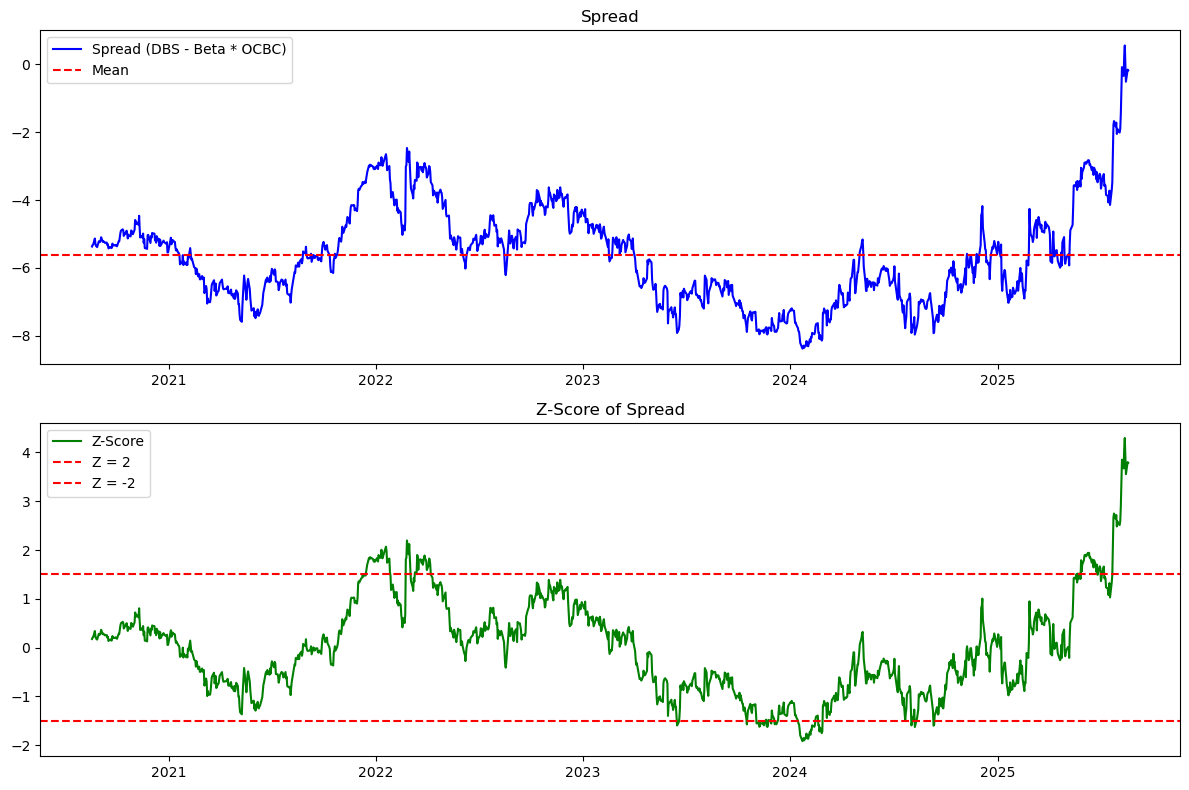

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
 
# Define start and end dates for a 5-year period
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=5)
 
# Fetch historical data
ocbc = yf.Ticker("O39.SI").history(start=start_date, end=end_date)['Close']
dbs = yf.Ticker("D05.SI").history(start=start_date, end=end_date)['Close']
 
# Ensure aligned dates
prices = pd.DataFrame({'OCBC': ocbc, 'DBS': dbs}).dropna()
 
# Linear regression to find the hedge ratio (beta)
x = add_constant(prices['OCBC'])  # OCBC as independent variable
y = prices['DBS']  # DBS as dependent variable
model = OLS(y, x).fit()
beta = model.params['OCBC']
 
# Calculate the spread
spread = prices['DBS'] - beta * prices['OCBC']
 
# Calculate z-score for the spread
spread_mean = spread.mean()
spread_std = spread.std()
z_score = (spread - spread_mean) / spread_std
 
# Plot the spread and z-score
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(spread, label='Spread (DBS - Beta * OCBC)', color='blue')
ax[0].axhline(spread_mean, color='red', linestyle='--', label='Mean')
ax[0].set_title('Spread')
ax[0].legend()
 
ax[1].plot(z_score, label='Z-Score', color='green')
ax[1].axhline(1.5, color='red', linestyle='--', label='Z = 2')
ax[1].axhline(-1.5, color='red', linestyle='--', label='Z = -2')
ax[1].set_title('Z-Score of Spread')
ax[1].legend()
plt.tight_layout()
plt.show()